# Project: Is the Galactic Plane Flat?

Implements the deliverables of HI1.tex sec. 8:

1. Build $W(\ell, b)$ on a coarser longitude grid ($\Delta \ell = 4^\circ$,
   manual line 499) that retains full $b$ sampling.
2. Warp curve $b_{\rm peak}(\ell)$ from per-column Gaussian fits.
3. Disk thickness $h_z(\ell)$ from the Gaussian FWHM, converted from
   degrees to kpc using the near-branch kinematic distance map.
4. The "spectacular colour image" (line 503) rendered three ways:
   (A) HSV blend, brightness $=W$ and hue $=\langle v_{\rm LSR}\rangle$;
   (B) two-panel composite $W$ and $\langle v\rangle$;
   (C) RGB tri-band (three disjoint $v$ slices into R/G/B channels).
5. Fourier representation of the warp, $b_{\rm peak}(\ell) =
   \sum_m a_m\cos(m\ell) + b_m\sin(m\ell)$ for $m = 1,2,3$.

Inputs:
- `artifacts/scan_data_products.pkl` (per-cell $T_B(v)$, $W$ map).
- `artifacts/galactic_plane_products.pkl` (kinematic distance map
  for converting $h_z$ from degrees to kpc).

In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit

from plotters import (
    plot_survey_mollweide,
    add_never_observable_overlay,
)
from ugradiolab.plotting import (
    TEXTWIDTH_IN, landscapewidth_figure, subpanels,
    SS_FINE, SS_STANDARD, LW_FINE, LW_LIGHT,
    NEUTRAL_COLOR, ALPHA_FAINT, ALPHA_STANDARD,
)

# --- Constants ---
R_SUN_KPC   = 8.5
V_SUN_KMS   = 220.0
HPBW_DEG    = 3.4

# --- Binning for the warp scan ---
L_BIN_DEG   = 4.0
B_MIN_FIT_DEG = -20.0
B_MAX_FIT_DEG =  20.0

# --- Colour-image setup ---
HUE_VMIN_KMS = -100.0
HUE_VMAX_KMS = +100.0
RGB_V_EDGES  = (-30.0, +30.0)   # blue: v<-30, green: -30<=v<+30, red: v>=+30

# --- Fourier warp model ---
M_HARMONICS = 3

# --- Paths ---
PRODUCTS_PATH    = Path('artifacts/scan_data_products.pkl')
PLANE_PATH       = Path('artifacts/galactic_plane_products.pkl')
OUTPUT_PATH      = Path('artifacts/galactic_warp_products.pkl')

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load `scan_data_products.pkl` and the kinematic distance map

In [2]:
with open(PRODUCTS_PATH, 'rb') as f:
    products = pickle.load(f)
with open(PLANE_PATH, 'rb') as f:
    plane = pickle.load(f)

cells_data    = products['cells']
v_lsr         = products['v_lsr_overlap']
dv_kms        = float(products['dv_kms'])
W_dict        = products['W']
moll_center_l = float(products['moll_center_l'])

# Kinematic distance map (l_fine x v_lsr) from notebook 1.
d_near_map = plane['distance_map_near']
l_fine_plane = plane['l_fine']
v_lsr_plane  = plane['v_lsr']

print(f'Loaded {len(cells_data)} cells.  '
      f'v_LSR: [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s,  '
      f'dv = {dv_kms:.3f} km/s')
print(f'Loaded near-branch distance map of shape {d_near_map.shape}')

Loaded 2652 cells.  v_LSR: [-164, 132] km/s,  dv = 0.660 km/s
Loaded near-branch distance map of shape (450, 721)


## 2. Build $W(\ell, b)$ on a coarser $\ell$-grid

Cells live on a brick-pattern grid; $\Delta b = 2^\circ$ in the
discrete grid. We sum integrated brightness $W = \int T_B\,dv$ per
cell, then bin by $\ell$ in $\Delta\ell = 4^\circ$ wraparound bins
(manual line 499 allows the coarser $\ell$ sampling for warp work).

Per-cell W finite for 2652 / 2652 cells
<v_LSR> finite for 2646 cells (W > 200 K km/s)
W range: [31, 9736] K km/s
<v_LSR> range: [-67, +48] km/s
l-bins: 91 of width 4.0 deg  (centres -88..272)
b-values: 46 from -20 to 70 deg
W_grid populated cells: 1464 / 4186


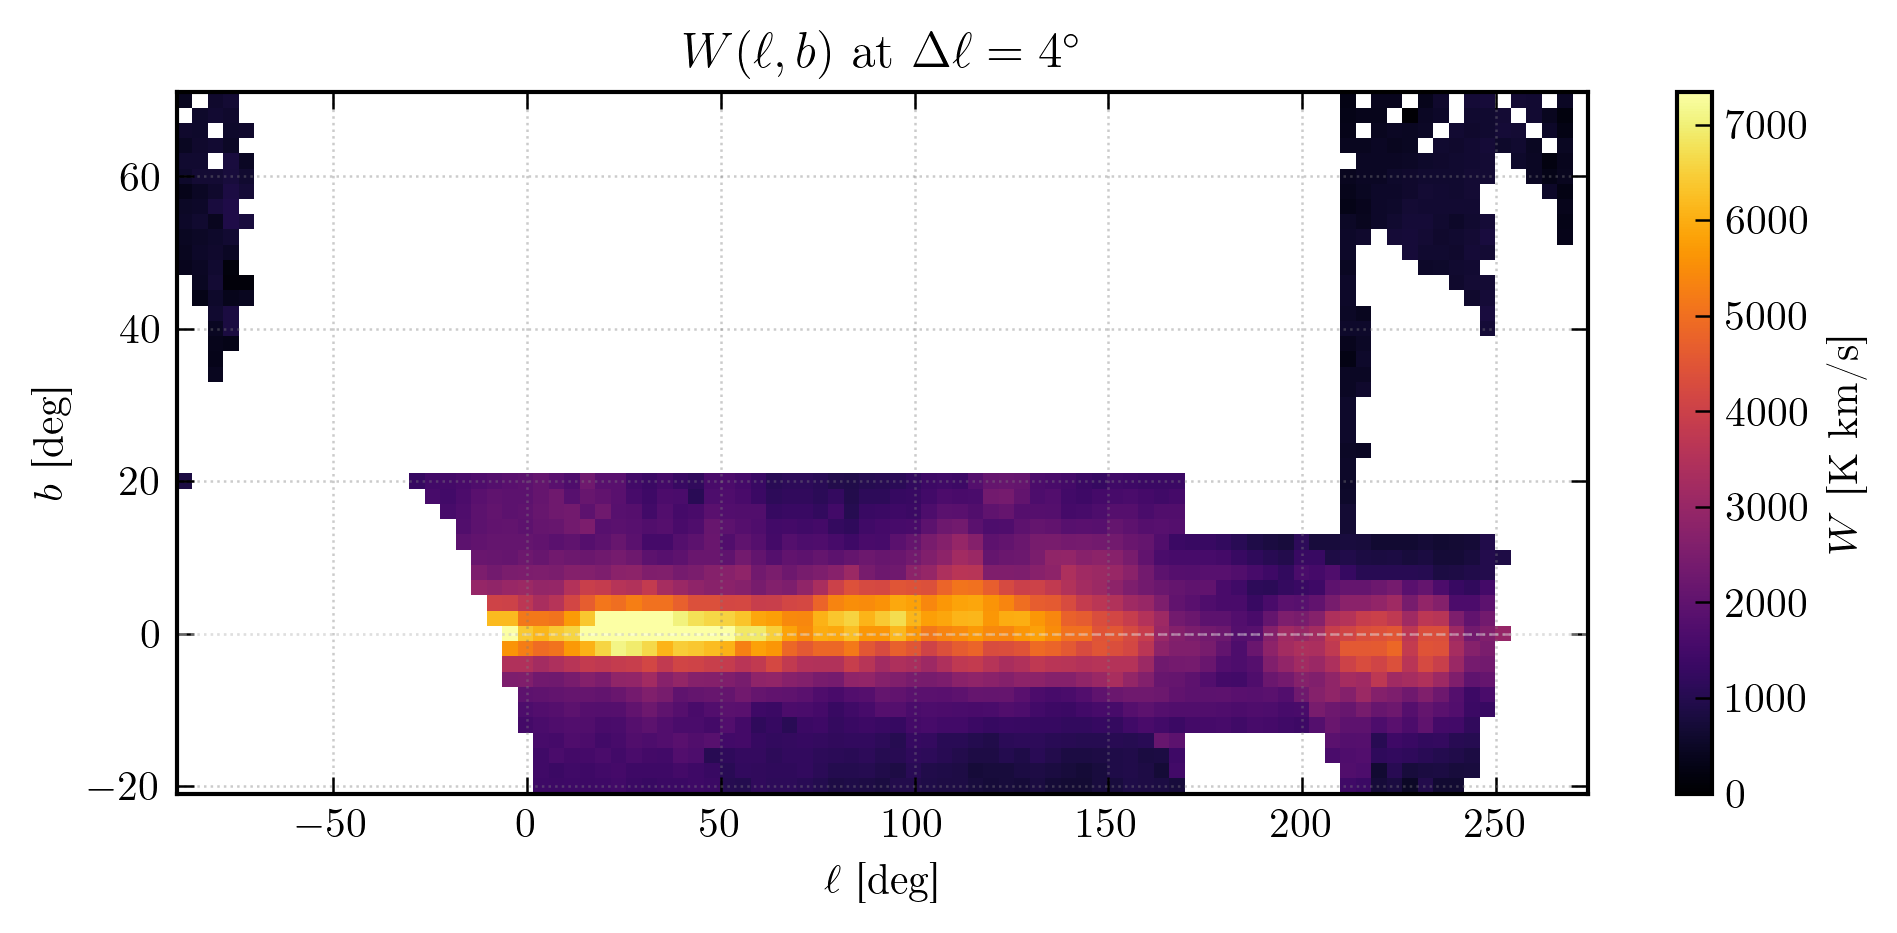

In [3]:
# Per-cell W and mean v_LSR (first moment).  vmean requires a positive
# brightness floor; otherwise sum(T_B * v) / sum(T_B) explodes when the
# denominator is near zero from a near-cancelling-noise cell.
W_MIN_VMEAN_KKMS = 200.0   # require W > this for <v> to be reliable

gl_arr = np.array([k[0] for k in cells_data.keys()])
gb_arr = np.array([k[1] for k in cells_data.keys()])
W_cell = np.full(len(cells_data), np.nan)
vmean_cell = np.full(len(cells_data), np.nan)
for i, ((gl, gb), entry) in enumerate(cells_data.items()):
    T_B = np.asarray(entry['T_B'], dtype=float)
    finite = np.isfinite(T_B)
    if finite.sum() < 8:
        continue
    Tf = T_B[finite]; vf = v_lsr[finite]
    W = float(np.sum(Tf) * dv_kms)
    if W <= 0:
        continue
    W_cell[i] = W
    if W >= W_MIN_VMEAN_KKMS:
        T_pos = np.clip(Tf, 0.0, None)
        if T_pos.sum() > 0:
            vmean_cell[i] = float(np.sum(vf * T_pos) / np.sum(T_pos))

valid = np.isfinite(W_cell)
vmean_valid_mask = np.isfinite(vmean_cell)
print(f'Per-cell W finite for {valid.sum()} / {len(cells_data)} cells')
print(f'<v_LSR> finite for {vmean_valid_mask.sum()} cells '
      f'(W > {W_MIN_VMEAN_KKMS:.0f} K km/s)')
print(f'W range: [{np.nanmin(W_cell):.0f}, {np.nanmax(W_cell):.0f}] K km/s')
print(f'<v_LSR> range: [{np.nanmin(vmean_cell):+.0f}, '
      f'{np.nanmax(vmean_cell):+.0f}] km/s')

# Coarse l-binning: l in [-60, 300) wrapped through center.
gl_wrapped = ((gl_arr + 90) % 360) - 90
l_bin_edges = np.arange(gl_wrapped.min() - 0.5, gl_wrapped.max() + L_BIN_DEG + 0.5, L_BIN_DEG)
l_bin_centres = 0.5 * (l_bin_edges[:-1] + l_bin_edges[1:])
b_vals = np.sort(np.unique(gb_arr))
print(f'l-bins: {len(l_bin_centres)} of width {L_BIN_DEG} deg  '
      f'(centres {l_bin_centres[0]:.0f}..{l_bin_centres[-1]:.0f})')
print(f'b-values: {len(b_vals)} from {b_vals[0]} to {b_vals[-1]} deg')

W_grid = np.full((len(l_bin_centres), len(b_vals)), np.nan)
n_grid = np.zeros_like(W_grid, dtype=int)
for w, l, b, ok in zip(W_cell, gl_wrapped, gb_arr, valid):
    if not ok:
        continue
    j = int(np.searchsorted(l_bin_edges, l, side='right') - 1)
    if j < 0 or j >= len(l_bin_centres):
        continue
    i_b = int(np.where(b_vals == b)[0][0])
    if np.isnan(W_grid[j, i_b]):
        W_grid[j, i_b] = w
        n_grid[j, i_b] = 1
    else:
        W_grid[j, i_b] = (W_grid[j, i_b] * n_grid[j, i_b] + w) / (n_grid[j, i_b] + 1)
        n_grid[j, i_b] += 1

print(f'W_grid populated cells: {np.isfinite(W_grid).sum()} / {W_grid.size}')

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.4))
pcm = ax.pcolormesh(l_bin_edges, np.concatenate([[b_vals[0] - 1], b_vals + 1]),
                    W_grid.T, cmap='inferno', shading='flat',
                    vmin=0, vmax=np.nanpercentile(W_grid, 99))
fig.colorbar(pcm, ax=ax, label=r'$W$ [K km/s]')
ax.axhline(0, color='w', lw=LW_FINE, ls='--', alpha=ALPHA_FAINT)
ax.set_xlabel(r'$\ell$ [deg]')
ax.set_ylabel(r'$b$ [deg]')
ax.set_title(rf'$W(\ell, b)$ at $\Delta\ell = {L_BIN_DEG:.0f}^\circ$')
plt.show()

## 3. Warp curve $b_{\rm peak}(\ell)$

For each $\ell$-bin, fit a single Gaussian $W(b) = A\exp[-(b - b_0)^2 / (2\sigma_b^2)] + C$
to the vertical profile. $b_{\rm peak} \equiv b_0$. Reject fits with
fewer than 5 finite $b$ samples or unphysical $\sigma_b$.

Gaussian fits succeeded in 69 / 91 l-bins


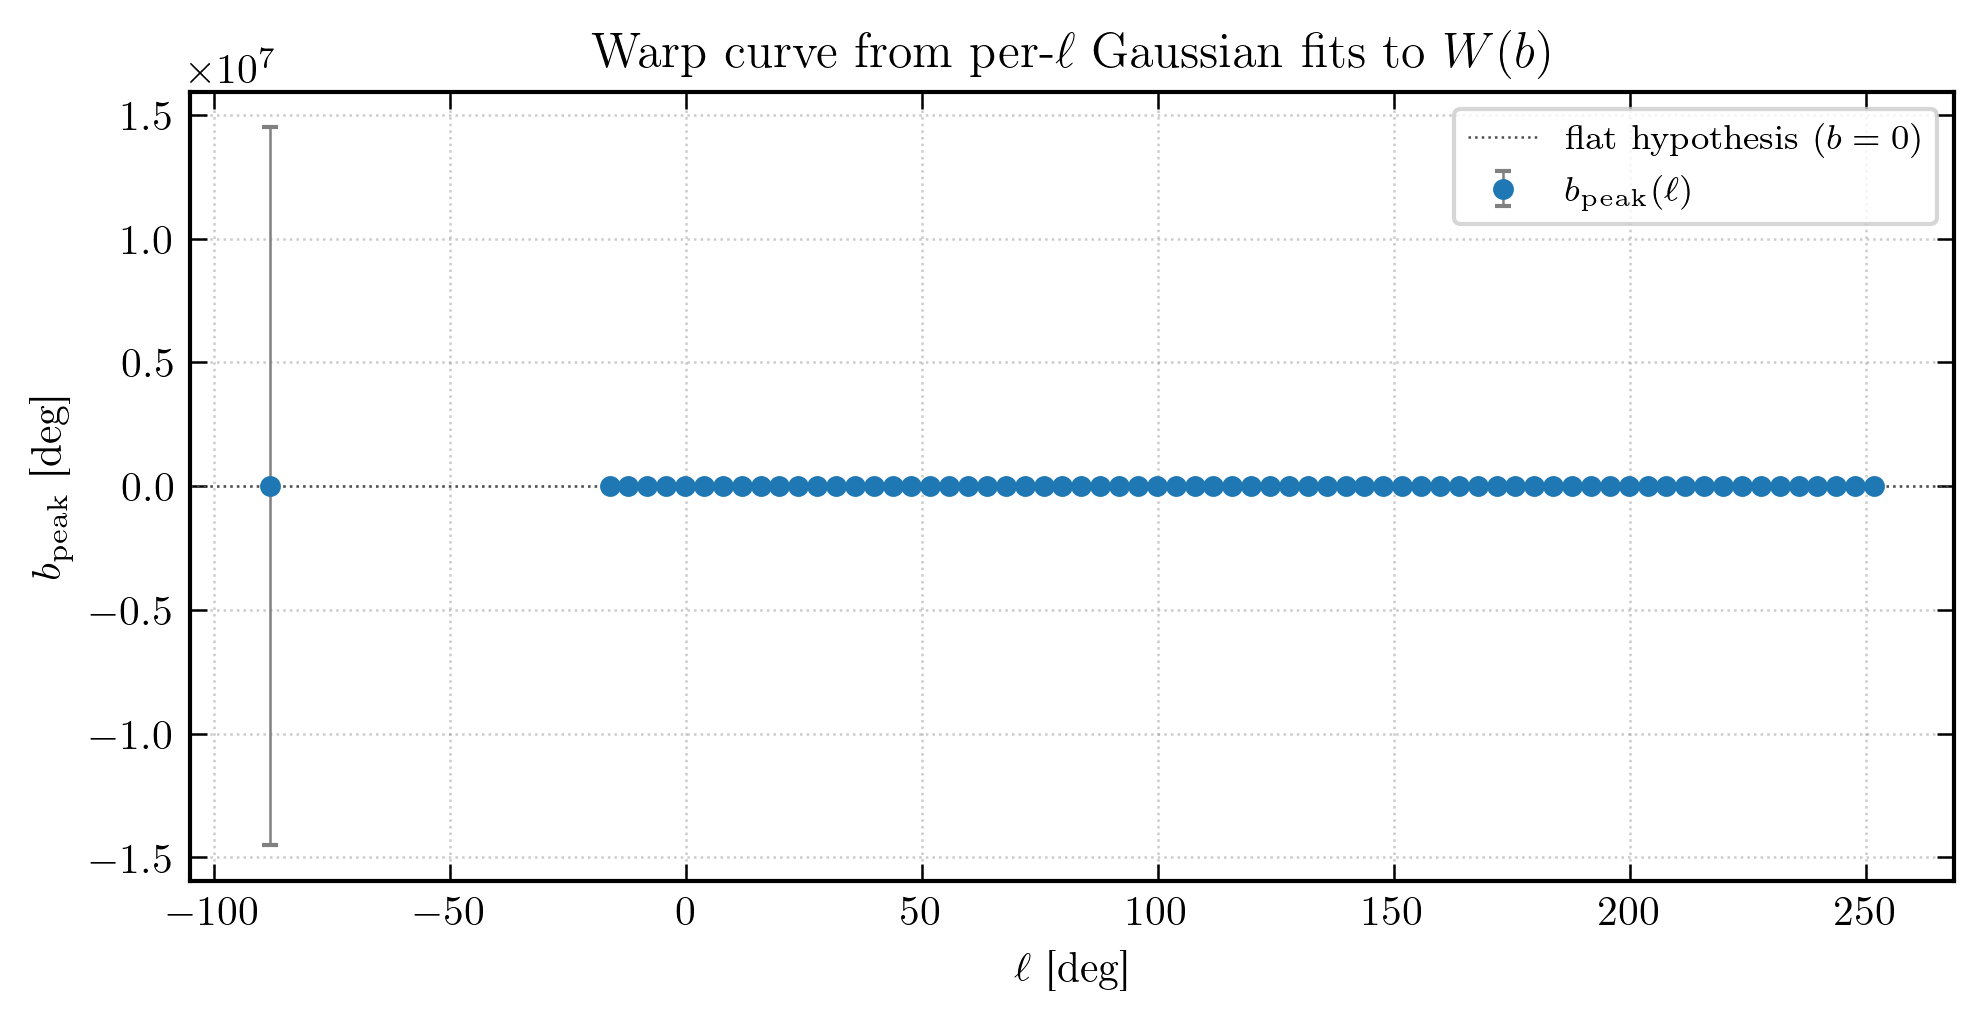

Chi^2 vs b_peak=0:  3356.2 / 69 dof   (reduced = 48.64).  p < 1e-3 implies a statistically significant warp.


In [4]:
def gauss(b, A, b0, sigma, C):
    return A * np.exp(-0.5 * ((b - b0) / sigma) ** 2) + C


b_peak = np.full(len(l_bin_centres), np.nan)
b_peak_err = np.full(len(l_bin_centres), np.nan)
sigma_b = np.full(len(l_bin_centres), np.nan)
sigma_b_err = np.full(len(l_bin_centres), np.nan)
A_amp = np.full(len(l_bin_centres), np.nan)

for j, lc in enumerate(l_bin_centres):
    yprof = W_grid[j]
    finite = np.isfinite(yprof) & (n_grid[j] > 0)
    if finite.sum() < 5:
        continue
    b_obs = b_vals[finite].astype(float)
    w_obs = yprof[finite]
    # Initial guess: amplitude = peak above floor, b0 = b at max, sigma=4 deg.
    A0 = float(np.max(w_obs) - np.min(w_obs))
    b0_init = float(b_obs[int(np.argmax(w_obs))])
    sig0 = 4.0
    C0 = float(np.min(w_obs))
    try:
        popt, pcov = curve_fit(
            gauss, b_obs, w_obs, p0=(A0, b0_init, sig0, C0),
            bounds=([0.0, B_MIN_FIT_DEG, 1.0, -np.inf],
                    [np.inf, B_MAX_FIT_DEG, 20.0, np.inf]),
            maxfev=2000,
        )
        perr = np.sqrt(np.diag(pcov))
        A_amp[j] = popt[0]
        b_peak[j] = popt[1]; b_peak_err[j] = perr[1]
        sigma_b[j] = popt[2]; sigma_b_err[j] = perr[2]
    except (RuntimeError, ValueError):
        continue

ok = np.isfinite(b_peak)
print(f'Gaussian fits succeeded in {ok.sum()} / {len(l_bin_centres)} l-bins')

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.45))
ax.errorbar(l_bin_centres[ok], b_peak[ok], yerr=b_peak_err[ok],
            fmt='o', color='C0', ms=4, ecolor='0.5', elinewidth=LW_FINE,
            capsize=2, label=r'$b_{\rm peak}(\ell)$')
ax.axhline(0, color='0.3', lw=LW_FINE, ls=':', label='flat hypothesis ($b=0$)')
ax.set_xlabel(r'$\ell$ [deg]')
ax.set_ylabel(r'$b_{\rm peak}$ [deg]')
ax.legend(loc='best', fontsize='small')
ax.set_title('Warp curve from per-$\\ell$ Gaussian fits to $W(b)$')
plt.show()

# Chi^2 against the flat hypothesis.
chi2_flat = float(np.nansum((b_peak[ok] / b_peak_err[ok]) ** 2))
dof = int(ok.sum())
print(f'Chi^2 vs b_peak=0:  {chi2_flat:.1f} / {dof} dof   '
      f'(reduced = {chi2_flat/max(dof,1):.2f}).  '
      f'p < 1e-3 implies a statistically significant warp.')

## 4. Disk thickness $h_z(\ell)$

Gaussian FWHM $= 2\sqrt{2\ln 2}\,\sigma_b$ in degrees. Convert to kpc
using the near-branch kinematic distance at the dominant emission's
$(\ell, v_{\rm LSR})$. We use the $v_{\rm LSR}$ that maximises
$T_B(v)$ in the cell at $(\ell, b = b_{\rm peak})$ as the
representative distance.

Dropped 3 l-bins from h_z analysis  (sightline never observable at b_peak from Leuschner).


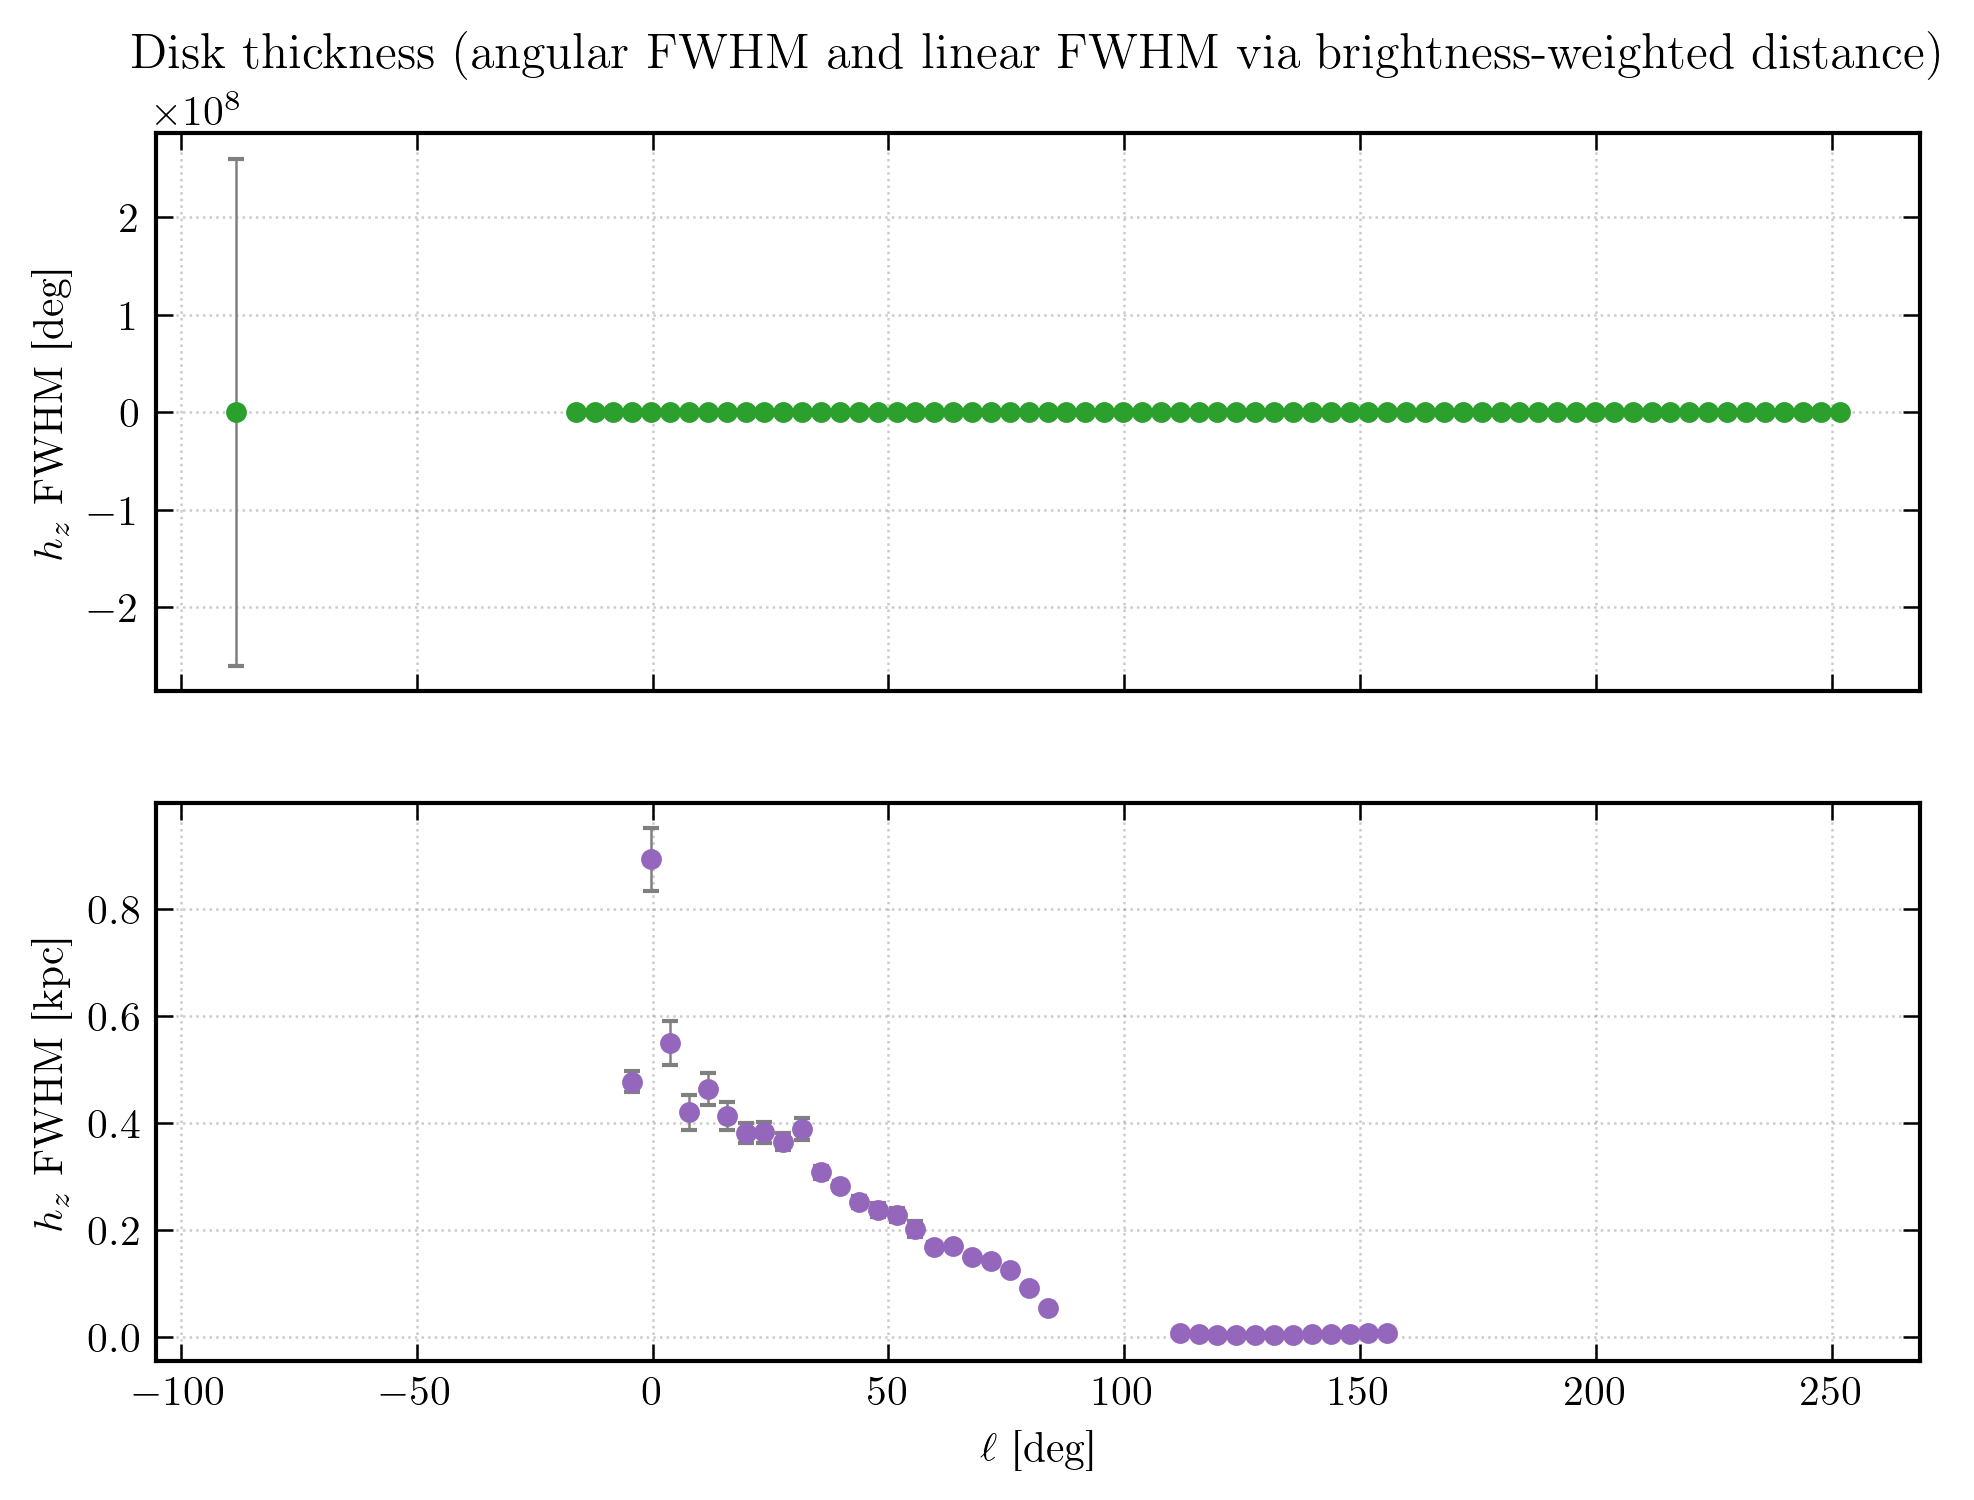

Median angular FWHM: 11.31 deg
Median brightness-weighted distance: 1.04 kpc
Median linear FWHM (near branch, observable l only): 0.17 kpc  (literature: HI scale height ~0.15-0.3 kpc)


In [5]:
from plotters import never_observable_mask

FWHM_FACTOR = 2.0 * np.sqrt(2.0 * np.log(2.0))
h_z_deg = FWHM_FACTOR * sigma_b
h_z_deg_err = FWHM_FACTOR * sigma_b_err

# Representative distance per l-bin: brightness-weighted near-branch distance
# at the cell closest to (lc, b_peak[j]).  Restricted to OBSERVABLE l-bins
# (where the (l, b_peak) sightline is reachable from Leuschner); elsewhere
# the near-branch distance is a rotation-curve extrapolation, not a
# measurement, and would propagate fake h_z values.
d_repr_kpc = np.full(len(l_bin_centres), np.nan)
n_unobs = 0
for j, lc in enumerate(l_bin_centres):
    if not np.isfinite(b_peak[j]):
        continue
    if bool(never_observable_mask(np.array([lc]),
                                   np.array([b_peak[j]]))[0]):
        n_unobs += 1
        continue
    distances = np.hypot(gl_wrapped - lc, gb_arr - b_peak[j])
    valid_cells = np.isfinite(W_cell) & (distances < L_BIN_DEG)
    if not valid_cells.any():
        continue
    i_cell = int(np.argmin(np.where(valid_cells, distances, np.inf)))
    gl, gb = gl_arr[i_cell], gb_arr[i_cell]
    T_B = np.asarray(cells_data[(gl, gb)]['T_B'], dtype=float)
    j_l = int(np.argmin(np.abs(l_fine_plane - lc)))
    d_col = d_near_map[:, j_l]
    valid_d = np.isfinite(T_B) & np.isfinite(d_col) & (d_col > 0) & (T_B > 0)
    if not valid_d.any():
        continue
    d_repr_kpc[j] = float(np.sum(T_B[valid_d] * d_col[valid_d])
                          / np.sum(T_B[valid_d]))

if n_unobs:
    print(f'Dropped {n_unobs} l-bins from h_z analysis  '
          f'(sightline never observable at b_peak from Leuschner).')

h_z_kpc = np.deg2rad(h_z_deg) * d_repr_kpc
h_z_kpc_err = np.deg2rad(h_z_deg_err) * d_repr_kpc
ok_thick = np.isfinite(h_z_kpc)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.7),
                          sharex=True)
ax = axes[0]
ax.errorbar(l_bin_centres[ok], h_z_deg[ok], yerr=h_z_deg_err[ok],
            fmt='o', color='C2', ms=4, ecolor='0.5', elinewidth=LW_FINE,
            capsize=2)
ax.set_ylabel(r'$h_z$ FWHM [deg]')
ax.set_title('Disk thickness (angular FWHM and linear FWHM via brightness-weighted distance)')

ax = axes[1]
ax.errorbar(l_bin_centres[ok_thick], h_z_kpc[ok_thick],
            yerr=h_z_kpc_err[ok_thick],
            fmt='o', color='C4', ms=4, ecolor='0.5', elinewidth=LW_FINE,
            capsize=2)
ax.set_xlabel(r'$\ell$ [deg]')
ax.set_ylabel(r'$h_z$ FWHM [kpc]')
plt.show()

print(f'Median angular FWHM: {np.nanmedian(h_z_deg):.2f} deg')
print(f'Median brightness-weighted distance: {np.nanmedian(d_repr_kpc):.2f} kpc')
print(f'Median linear FWHM (near branch, observable l only): '
      f'{np.nanmedian(h_z_kpc):.2f} kpc  '
      f'(literature: HI scale height ~0.15-0.3 kpc)')

## 5. Colour image -- variant A: HSV blend (single panel)

Brightness $V = W(\ell, b)$ (log-stretched), hue $H = \langle v_{\rm LSR}\rangle$
mapped onto the hue circle over $[-100, +100]$ km/s, saturation $S = 1$.
The combined HSV $\to$ RGB image is placed on a Mollweide axis.

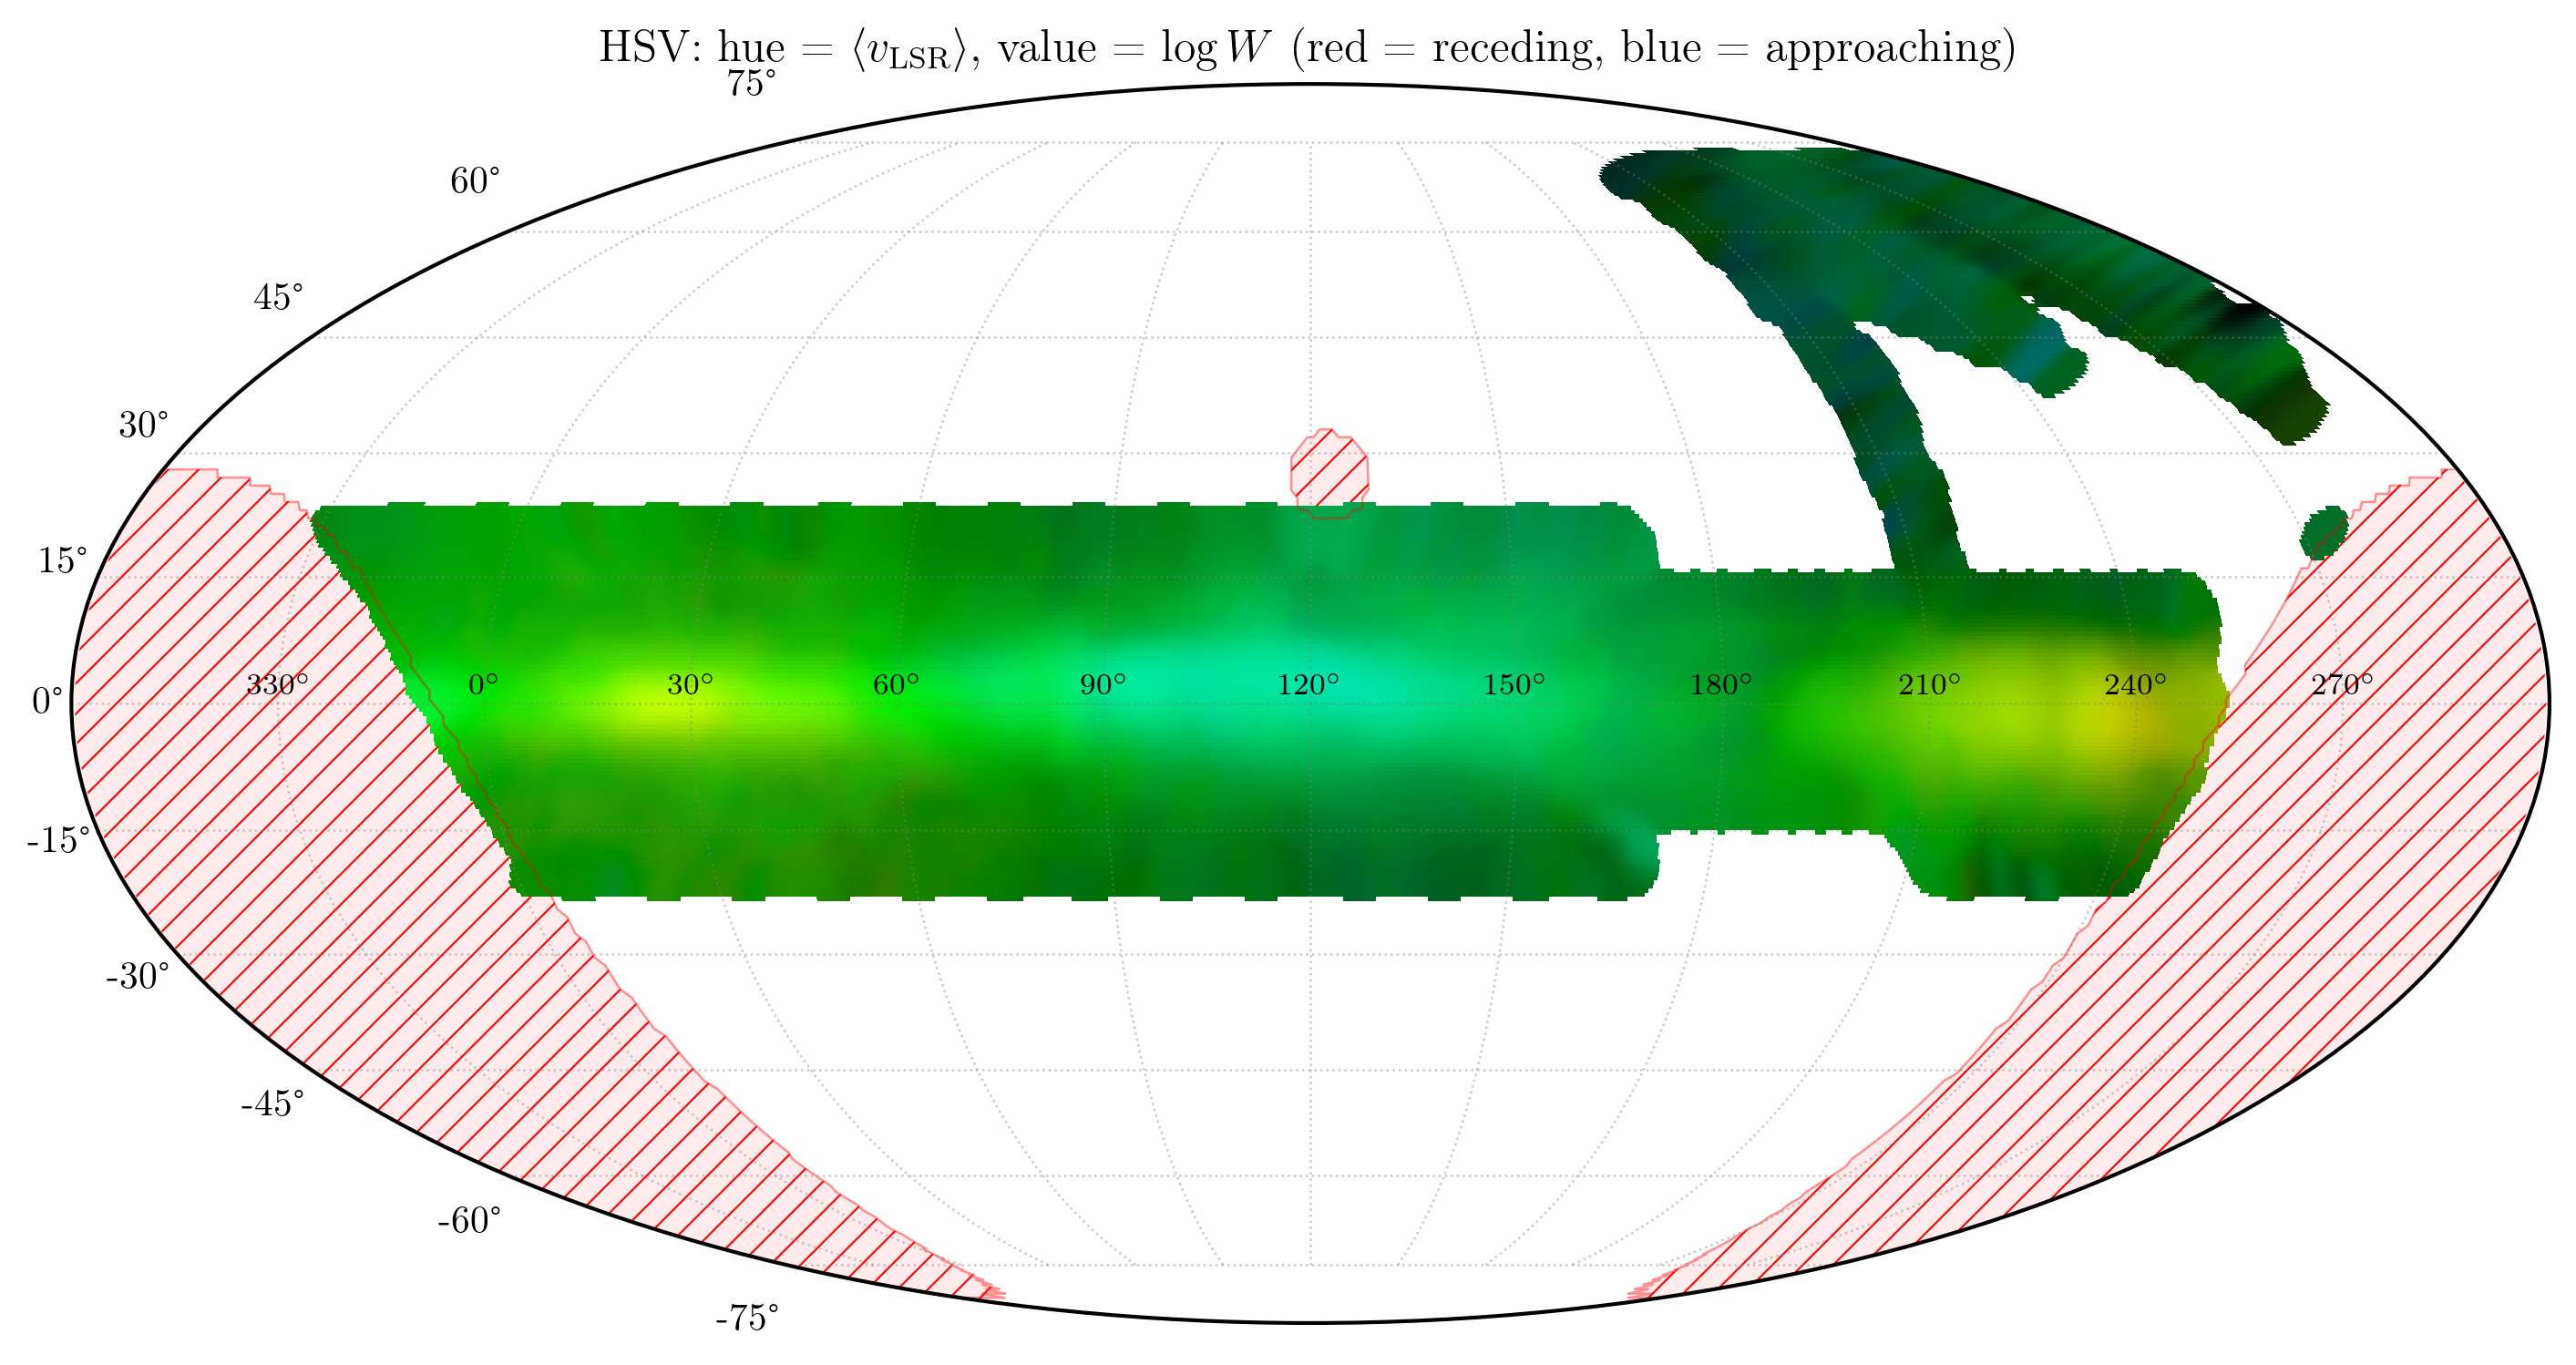

In [6]:
# --- Reusable FFT-based beam-weighted gridder --------------------------------
# Same logic as plotters.plot_survey_mollweide_gridded but exposes the raw
# (numerator, denominator) sinusoidal-projection grids so we can grid two
# quantities (W and W*v) with the same kernel and reduce them into a single
# brightness-weighted velocity map.
from scipy.signal import fftconvolve
from scipy.ndimage import map_coordinates

PIXEL_DEG = 0.5
CUTOFF_HPBW = 2.0


def beam_weighted_grid(gl_arr, gb_arr, vals, weights=None,
                      center_l=moll_center_l, pixel_deg=PIXEL_DEG,
                      hpbw_deg=HPBW_DEG, cutoff_hpbw=CUTOFF_HPBW,
                      min_weight=0.1):
    '''FFT beam-convolved gridded estimator on a Mollweide (l, b) frame.

    Returns dict with keys: img (l_pixels x b_pixels in (l, b)), l_centres,
    b_centres, num_grid, den_grid, num_conv, den_conv (intermediate
    sinusoidal-projection arrays so callers can blend multiple quantities).
    '''
    sigma_deg = hpbw_deg / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    cutoff_deg = cutoff_hpbw * hpbw_deg

    gl_shifted = (np.asarray(gl_arr) - center_l + 180.0) % 360.0 - 180.0
    gb = np.asarray(gb_arr)

    half = pixel_deg / 2.0
    u_centres = np.arange(-180.0 + half, 180.0, pixel_deg)
    v_centres = np.arange(-90.0 + half, 90.0, pixel_deg)
    nu, nv = len(u_centres), len(v_centres)

    u_samp = gl_shifted * np.cos(np.deg2rad(gb))
    v_samp = gb

    vals = np.asarray(vals, dtype=float)
    finite = np.isfinite(vals)
    if weights is None:
        w_samp = finite.astype(float)
    else:
        w_samp = np.asarray(weights, dtype=float) * finite

    iu = np.clip(np.round((u_samp - u_centres[0]) / pixel_deg).astype(int),
                 0, nu - 1)
    iv = np.clip(np.round((v_samp - v_centres[0]) / pixel_deg).astype(int),
                 0, nv - 1)

    num_grid = np.zeros((nv, nu))
    den_grid = np.zeros((nv, nu))
    np.add.at(num_grid, (iv, iu), np.where(finite, vals, 0.0) * w_samp)
    np.add.at(den_grid, (iv, iu), w_samp)

    sigma_pix = sigma_deg / pixel_deg
    half_kernel = int(np.ceil(cutoff_deg / pixel_deg))
    k_axis = np.arange(-half_kernel, half_kernel + 1)
    KX, KY = np.meshgrid(k_axis, k_axis)
    r2_pix2 = KX ** 2 + KY ** 2
    kernel = np.exp(-0.5 * r2_pix2 / sigma_pix ** 2)
    kernel[r2_pix2 > (cutoff_deg / pixel_deg) ** 2] = 0.0

    num_conv = fftconvolve(num_grid, kernel, mode='same')
    den_conv = fftconvolve(den_grid, kernel, mode='same')

    l_centres = np.arange(-180.0 + half, 180.0, pixel_deg)
    b_centres = np.arange(-90.0 + half, 90.0, pixel_deg)
    LL, BB = np.meshgrid(l_centres, b_centres)
    U_out = LL * np.cos(np.deg2rad(BB))
    iu_o = (U_out - u_centres[0]) / pixel_deg
    iv_o = (BB - v_centres[0]) / pixel_deg
    num_out = map_coordinates(num_conv, [iv_o, iu_o], order=1,
                              mode='constant', cval=0.0)
    den_out = map_coordinates(den_conv, [iv_o, iu_o], order=1,
                              mode='constant', cval=0.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        img = np.where(den_out > min_weight, num_out / den_out, np.nan)

    return {
        'img':       img,
        'l_centres': l_centres,
        'b_centres': b_centres,
        'num_conv':  num_conv,
        'den_conv':  den_conv,
        'num_out':   num_out,
        'den_out':   den_out,
        'u_centres': u_centres,
        'v_centres': v_centres,
        'pixel_deg': pixel_deg,
        'sigma_deg': sigma_deg,
    }


# --- HSV blend: brightness from W, hue from <v>=sum(W*v)/sum(W) -------------
gl_valid = gl_arr[valid]; gb_valid = gb_arr[valid]
W_valid  = W_cell[valid]; vmean_valid_arr = vmean_cell[valid]

# Grid 1: numerator = sum(W) at each pixel; weight = 1 per cell.
W_grid_info = beam_weighted_grid(gl_valid, gb_valid, W_valid)
# Grid 2: numerator = sum(W * v); weight = 1 per cell again, with vals = v_mean
# and per-cell weight = W -> sum_cell W*v / sum_cell W = brightness-weighted v.
v_grid_info = beam_weighted_grid(gl_valid, gb_valid, vmean_valid_arr,
                                 weights=W_valid)

W_img = W_grid_info['img']
vmean_img = v_grid_info['img']
l_centres = W_grid_info['l_centres']
b_centres = W_grid_info['b_centres']

# HSV channels.
W_finite = W_img[np.isfinite(W_img) & (W_img > 0)]
if W_finite.size:
    W_log = np.log10(np.clip(W_img, np.nanmin(W_finite), None))
    lo, hi = np.nanmin(W_log), np.nanmax(W_log)
    W_norm = (W_log - lo) / (hi - lo + 1e-9)
else:
    W_norm = np.zeros_like(W_img)
V = np.clip(np.nan_to_num(W_norm, nan=0.0), 0.0, 1.0)

hue_norm = np.clip((vmean_img - HUE_VMIN_KMS) / (HUE_VMAX_KMS - HUE_VMIN_KMS),
                   0.0, 1.0)
H = 0.66 * (1.0 - hue_norm)   # 0 (red) at +vmax, 0.66 (blue) at -vmax
S = np.where(np.isfinite(vmean_img), 1.0, 0.0)
H = np.nan_to_num(H, nan=0.0)

hsv = np.stack([H, S, V], axis=-1)
rgb = mcolors.hsv_to_rgb(hsv)
mask_img = ~np.isfinite(vmean_img) | ~np.isfinite(W_img)
rgba = np.concatenate([rgb, np.where(mask_img, 0.0, 1.0)[..., None]], axis=-1)

# Crop to the observed |b| <= 22 band for display.
b_mask_disp = (b_centres > -22.5) & (b_centres < 22.5)

fig, _ax = landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, color=NEUTRAL_COLOR, alpha=ALPHA_FAINT)

l_edges = np.deg2rad(np.arange(-180.0, 180.0 + PIXEL_DEG, PIXEL_DEG))
b_edges = np.deg2rad(np.arange(-90.0, 90.0 + PIXEL_DEG, PIXEL_DEG))
ax.pcolormesh(l_edges, b_edges, rgba, shading='flat')

add_never_observable_overlay(ax, center_l=moll_center_l,
                             latitude_deg=37.9183, min_alt_deg=17,
                             max_alt_deg=83, az_min_deg=7, az_max_deg=348)

tick_locs = np.arange(-150, 180, 30)
tick_labels = [rf"{int((t + moll_center_l) % 360)}$^\circ$" for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_title(r'HSV: hue = $\langle v_{\rm LSR}\rangle$, value = $\log W$  '
             r'(red = receding, blue = approaching)')
plt.show()

## 6. Colour image -- variant B: two-panel composite

Side-by-side Mollweide of $W(\ell, b)$ and $\langle v_{\rm LSR}\rangle(\ell, b)$
on shared axes, using `plot_survey_mollweide` (per-cell scatter).

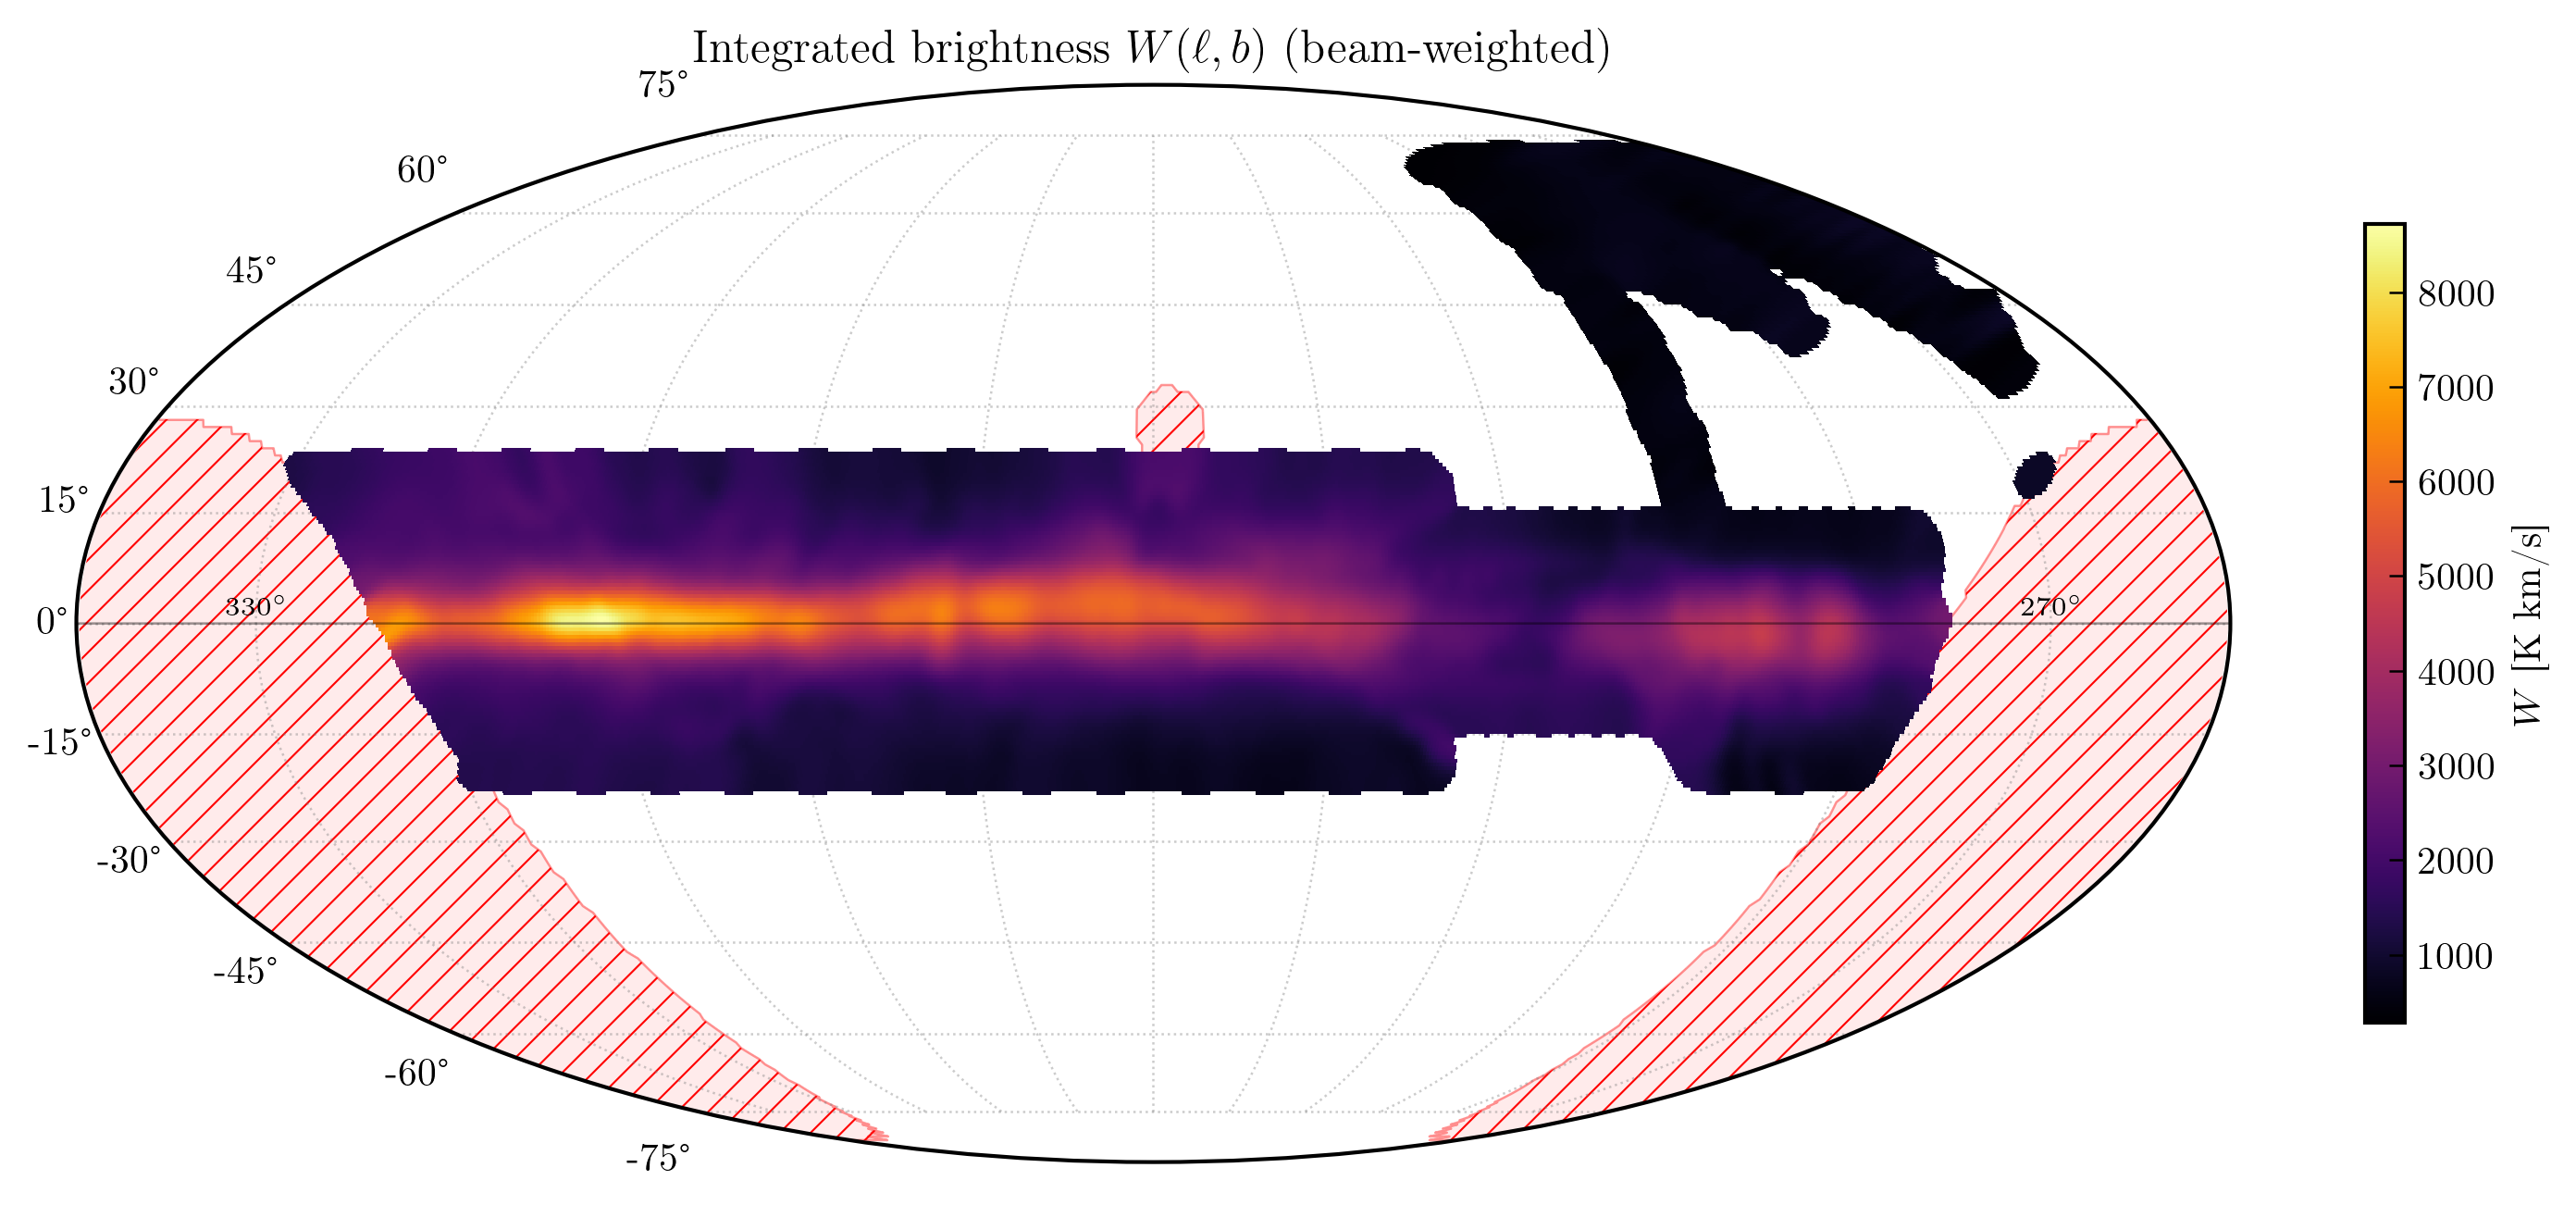

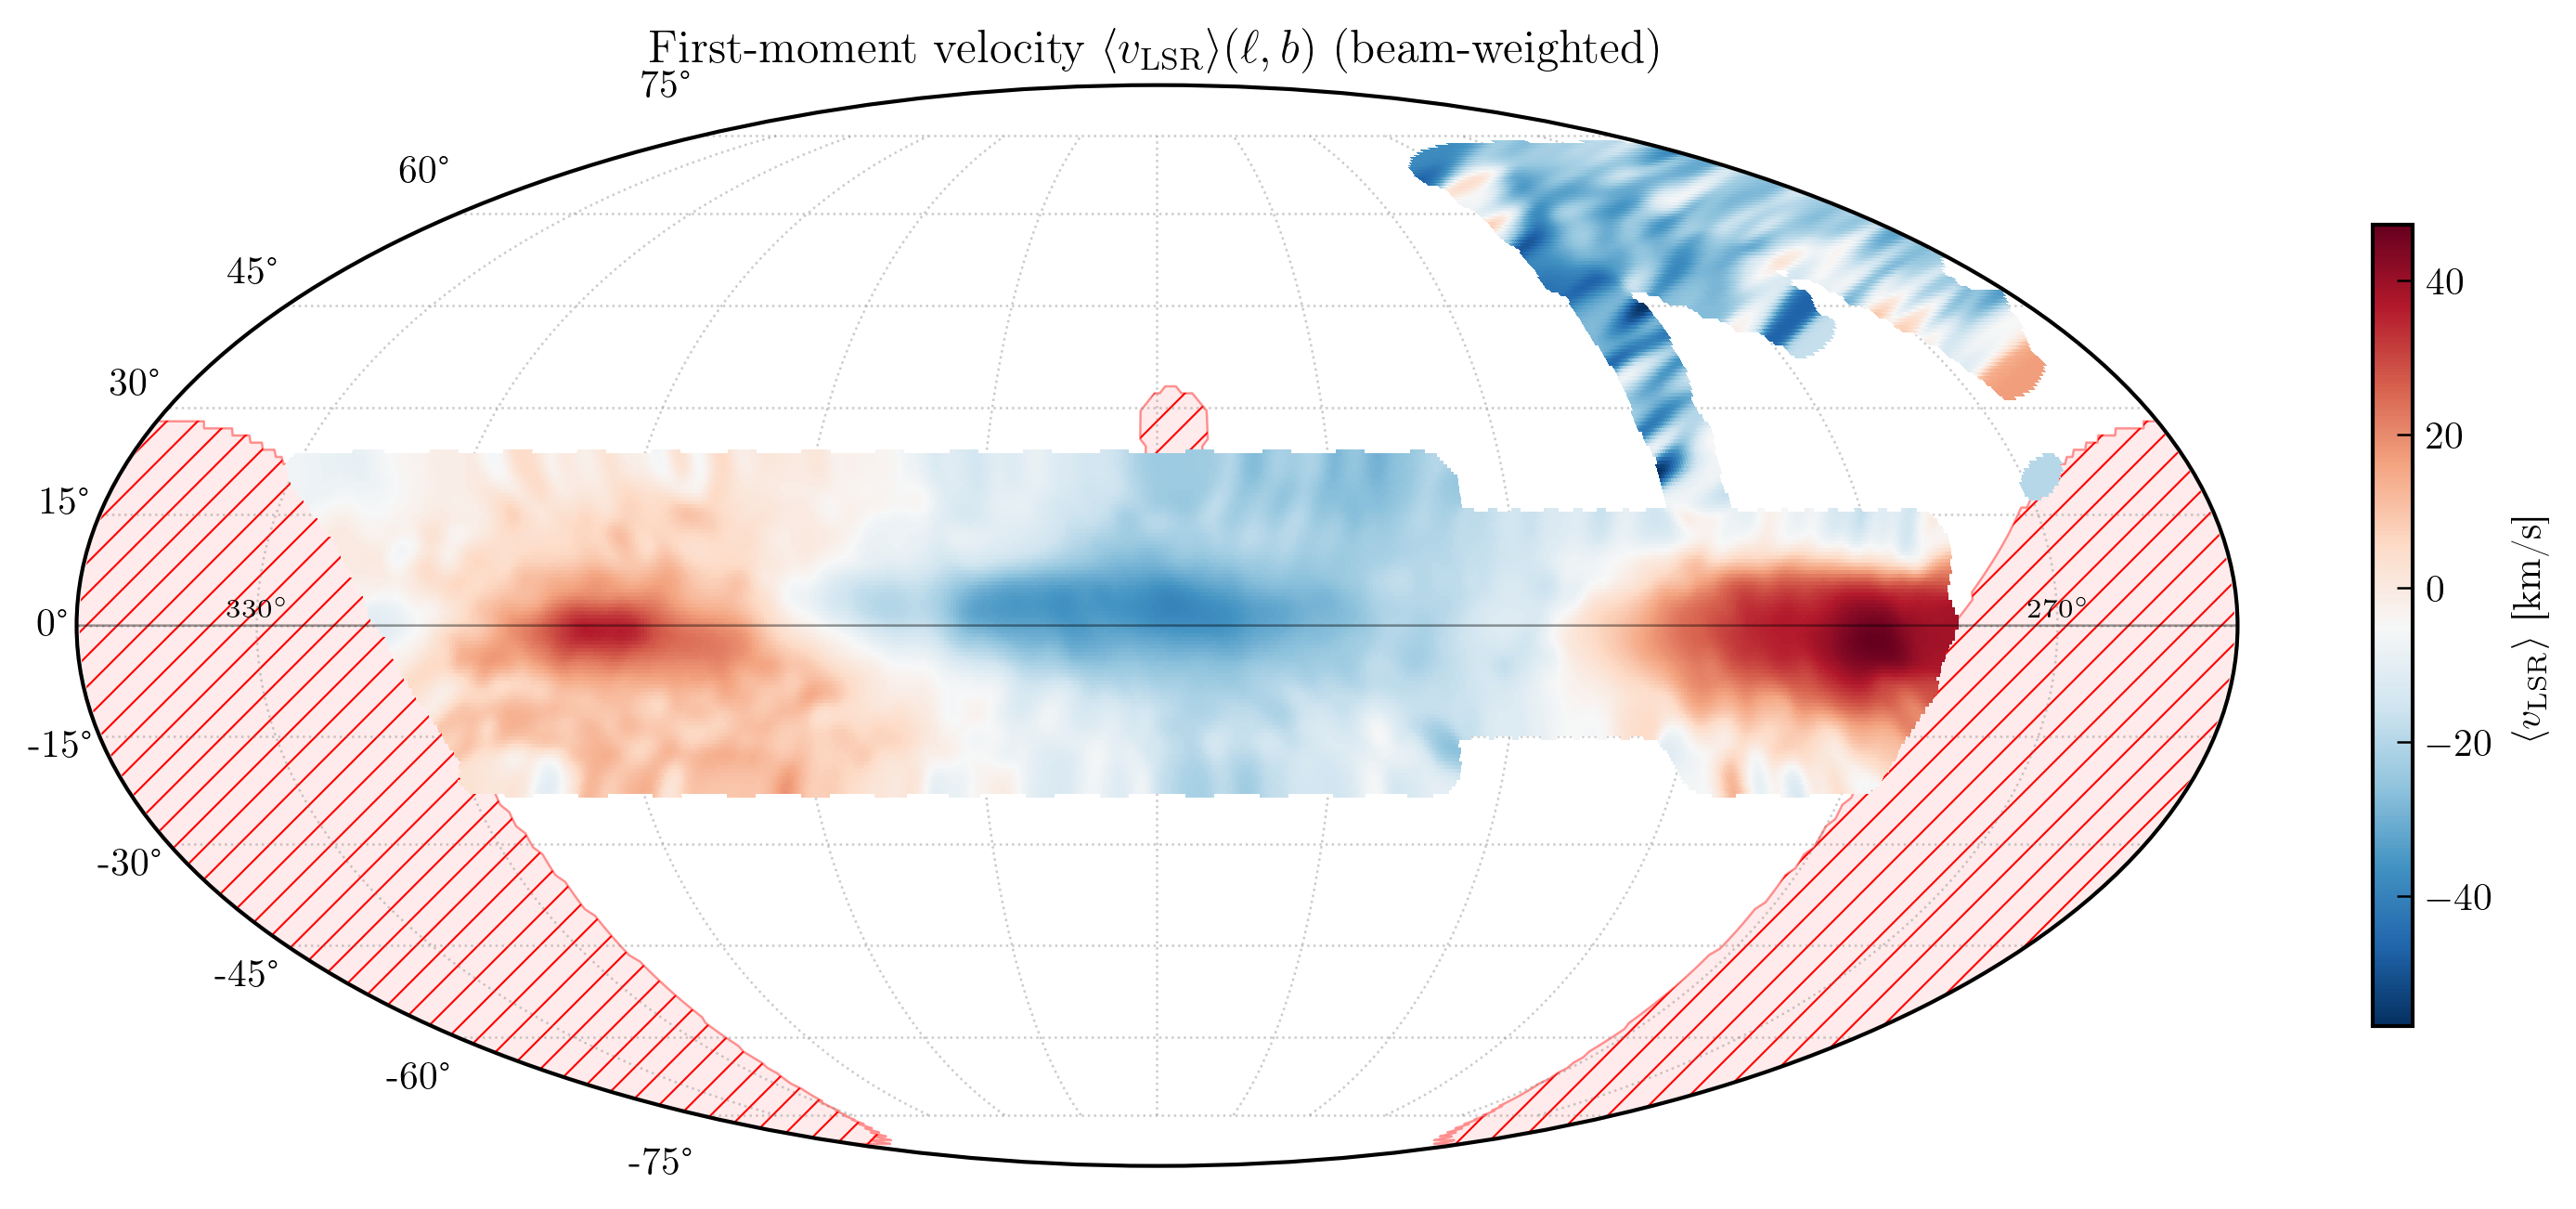

In [7]:
from plotters import plot_survey_mollweide_gridded

vmean_valid_mask = np.isfinite(vmean_cell)
both_valid = valid & vmean_valid_mask

fig_W, ax_W = plot_survey_mollweide_gridded(
    gl_arr[both_valid], gb_arr[both_valid], W_cell[both_valid],
    center_l=moll_center_l,
    cbar_label=r'$W$ [K km/s]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=r'Integrated brightness $W(\ell, b)$ (beam-weighted)',
)
plt.show()

fig_v, ax_v = plot_survey_mollweide_gridded(
    gl_arr[both_valid], gb_arr[both_valid], vmean_cell[both_valid],
    center_l=moll_center_l,
    cbar_label=r'$\langle v_{\rm LSR}\rangle$ [km/s]',
    cmap='RdBu_r',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=r'First-moment velocity $\langle v_{\rm LSR}\rangle(\ell, b)$ '
          r'(beam-weighted)',
)
plt.show()

## 7. Colour image -- variant C: RGB tri-band

Three velocity slices into R/G/B channels:
- **Red**: $W$ over $v_{\rm LSR} \geq +30$ km/s (receding).
- **Green**: $W$ over $-30 \leq v_{\rm LSR} < +30$ km/s (near-zero).
- **Blue**: $W$ over $v_{\rm LSR} < -30$ km/s (approaching).

Each channel is independently normalised so the rotational dipole
across $\ell$ shows as a red/blue gradient.

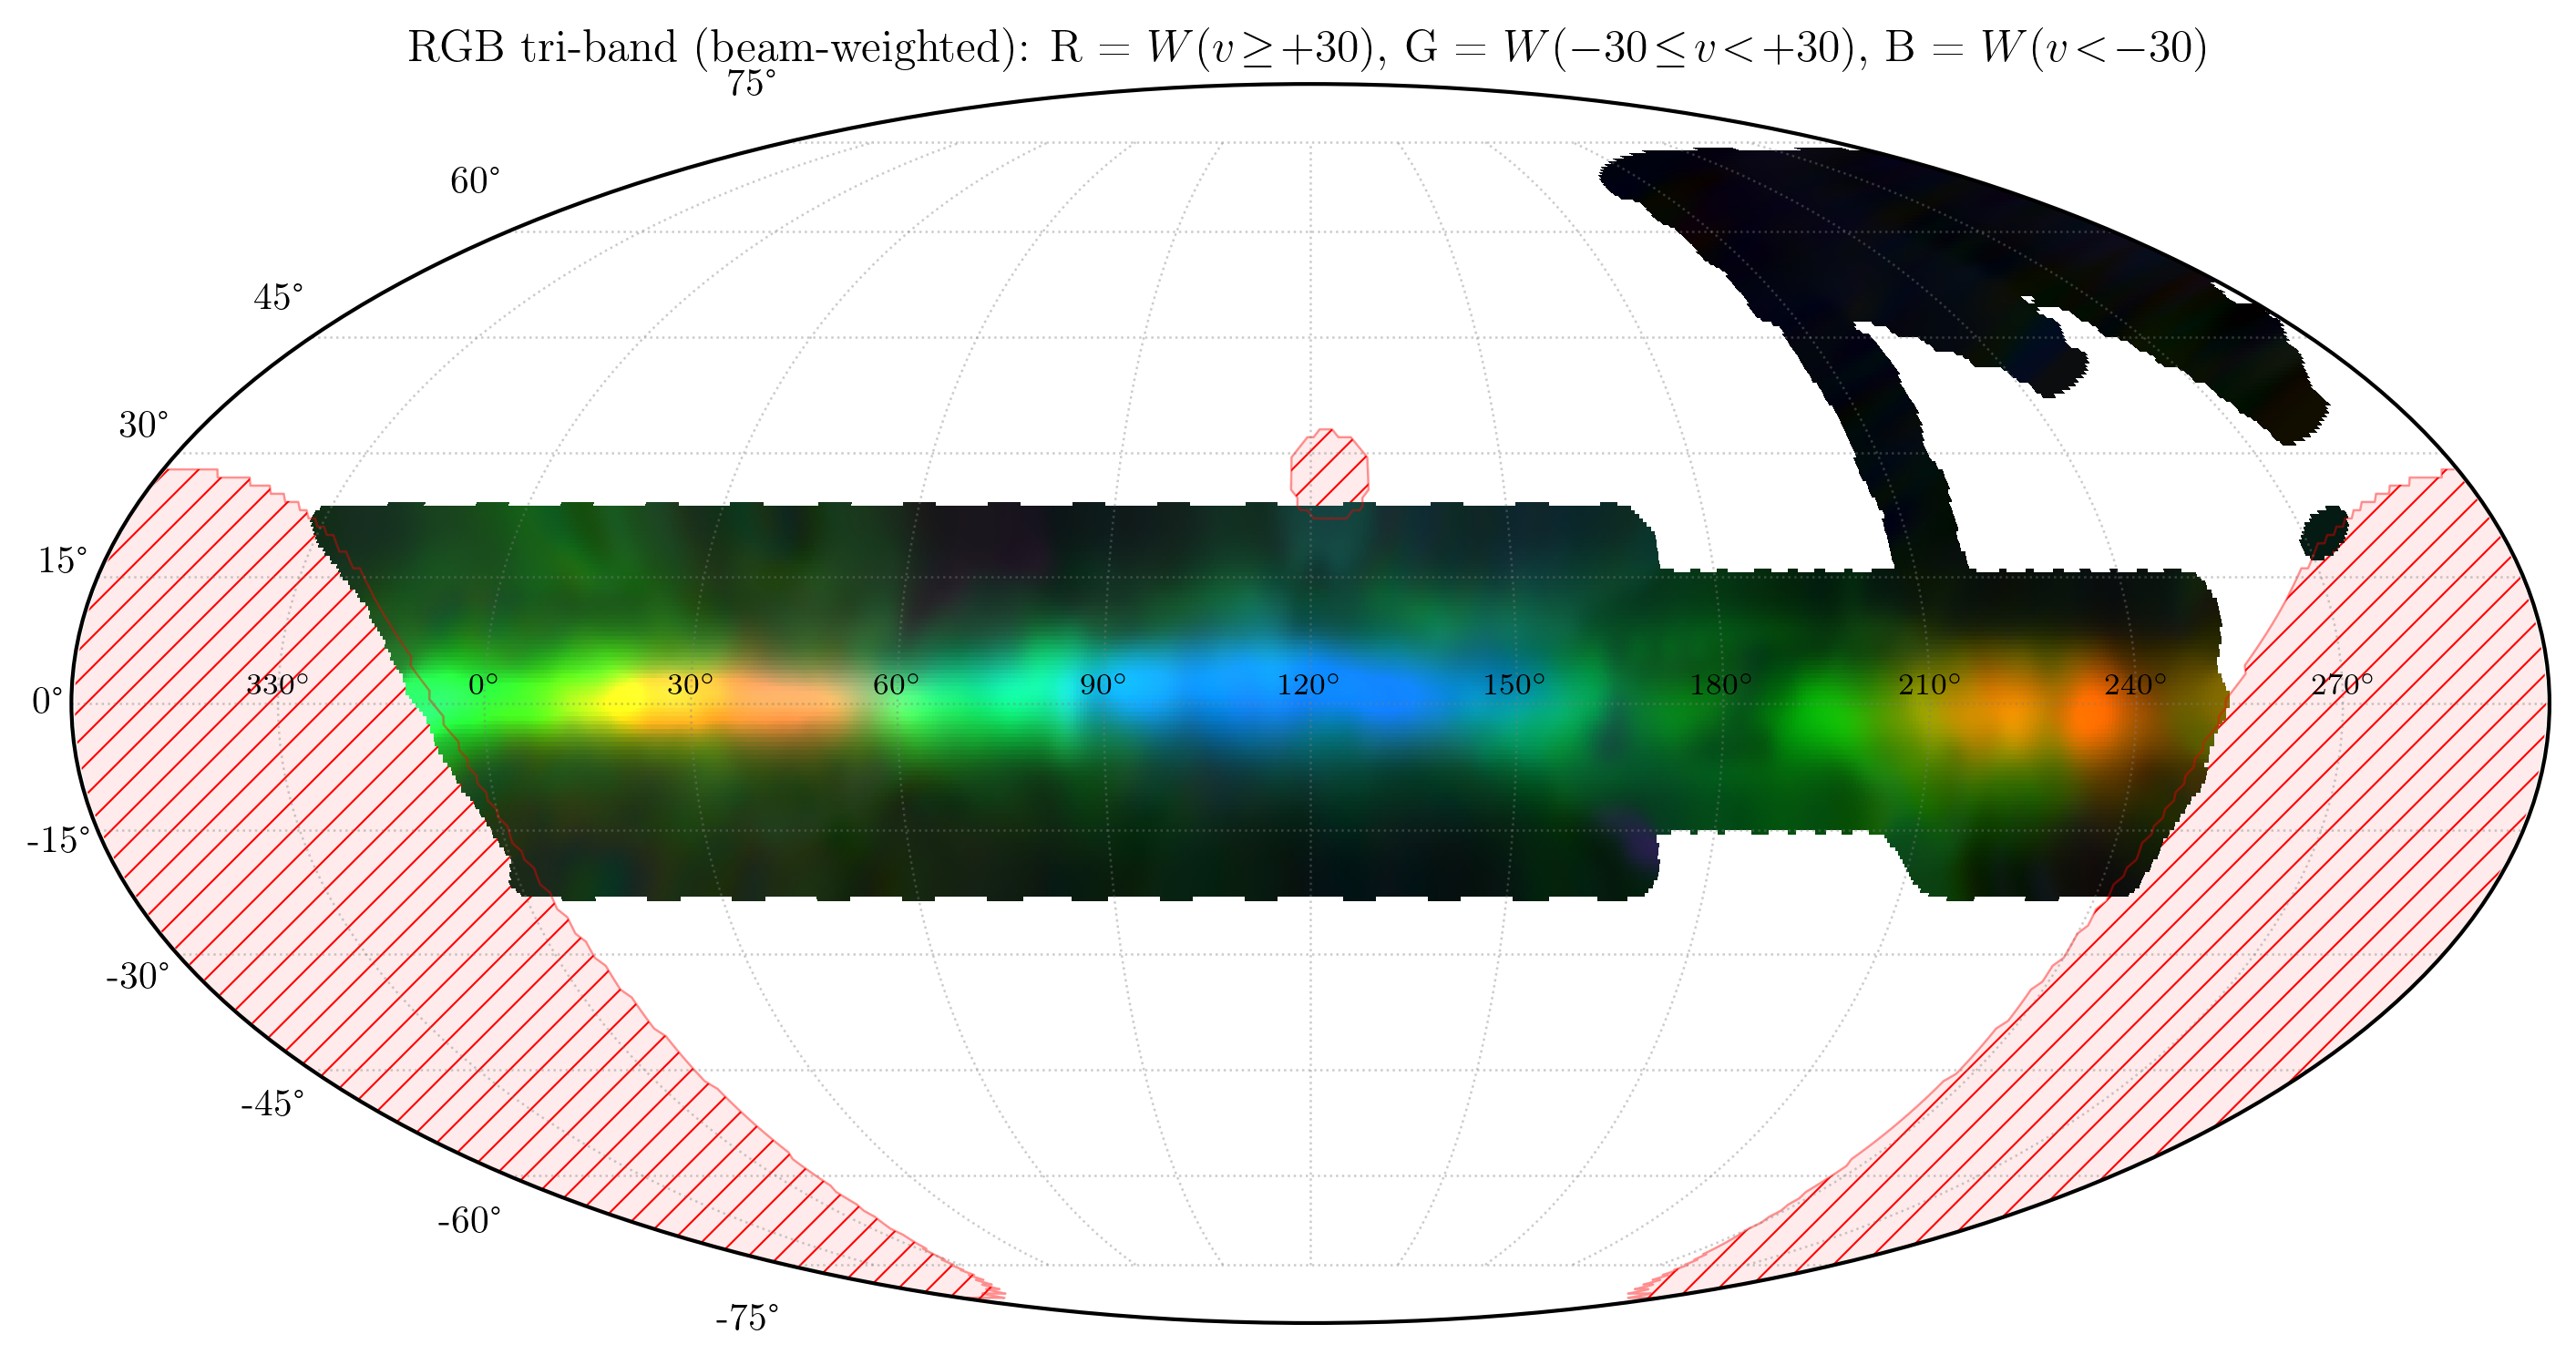

In [8]:
V_BLUE_HI, V_RED_LO = RGB_V_EDGES

W_blue  = np.full(len(cells_data), np.nan)
W_green = np.full_like(W_blue, np.nan)
W_red   = np.full_like(W_blue, np.nan)
mask_blue  = v_lsr <  V_BLUE_HI
mask_green = (v_lsr >= V_BLUE_HI) & (v_lsr < V_RED_LO)
mask_red   = v_lsr >= V_RED_LO

for i, ((gl, gb), entry) in enumerate(cells_data.items()):
    T_B = np.asarray(entry['T_B'], dtype=float)
    if not np.isfinite(T_B).any():
        continue
    finite = np.isfinite(T_B)
    W_blue[i]  = float(np.nansum(T_B[finite & mask_blue]))  * dv_kms
    W_green[i] = float(np.nansum(T_B[finite & mask_green])) * dv_kms
    W_red[i]   = float(np.nansum(T_B[finite & mask_red]))   * dv_kms

# Grid each channel via the same FFT beam-weighted gridder, then stack.
R_grid_info = beam_weighted_grid(gl_arr[valid], gb_arr[valid], W_red[valid])
G_grid_info = beam_weighted_grid(gl_arr[valid], gb_arr[valid], W_green[valid])
B_grid_info = beam_weighted_grid(gl_arr[valid], gb_arr[valid], W_blue[valid])


def normalise_clip(x, lo_pct=1, hi_pct=99):
    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x)
    pos = x[finite & (x > 0)]
    lo = np.nanpercentile(pos, lo_pct) if pos.size else 0.0
    hi = np.nanpercentile(pos, hi_pct) if pos.size else 1.0
    return np.clip((np.nan_to_num(x, nan=0.0) - lo) / max(hi - lo, 1e-6),
                   0.0, 1.0)


R_chan = normalise_clip(R_grid_info['img'])
G_chan = normalise_clip(G_grid_info['img'])
B_chan = normalise_clip(B_grid_info['img'])
RGB_img = np.stack([R_chan, G_chan, B_chan], axis=-1)

# Mask pixels with no data in any channel.
mask_any = (np.isfinite(R_grid_info['img']) |
             np.isfinite(G_grid_info['img']) |
             np.isfinite(B_grid_info['img']))
RGBA_img = np.concatenate([RGB_img, mask_any[..., None].astype(float)],
                          axis=-1)

# Per-cell array for export (consumed by section 9 below).
RGB_per_cell = np.stack([normalise_clip(W_red),
                          normalise_clip(W_green),
                          normalise_clip(W_blue)], axis=1)

fig, _ax = landscapewidth_figure(5)
_ax.remove()
ax = fig.add_subplot(111, projection='mollweide')
ax.grid(True, color=NEUTRAL_COLOR, alpha=ALPHA_FAINT)

l_edges = np.deg2rad(np.arange(-180.0, 180.0 + PIXEL_DEG, PIXEL_DEG))
b_edges = np.deg2rad(np.arange(-90.0, 90.0 + PIXEL_DEG, PIXEL_DEG))
ax.pcolormesh(l_edges, b_edges, RGBA_img, shading='flat')

add_never_observable_overlay(ax, center_l=moll_center_l,
                              latitude_deg=37.9183, min_alt_deg=17,
                              max_alt_deg=83, az_min_deg=7, az_max_deg=348)
tick_locs = np.arange(-150, 180, 30)
tick_labels = [rf"{int((t + moll_center_l) % 360)}$^\circ$" for t in tick_locs]
ax.set_xticks(np.deg2rad(tick_locs))
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_title(r'RGB tri-band (beam-weighted): R = $W(v\!\geq\!+30)$,  '
             r'G = $W(-30\!\leq\!v\!<\!+30)$,  B = $W(v\!<\!-30)$')
plt.show()

## 8. Fourier representation of the warp

Fit $b_{\rm peak}(\ell) = \sum_{m=1}^{M} [a_m\cos(m\ell) + b_m\sin(m\ell)]$
on the observed-$\ell$ range only. Manual sec. 8 flags the Southern
Galaxy gap (line 508); we mark the unconstrained $\ell$ range explicitly
in the plot. Levine, Blitz & Heiles 2006 report the warp is dominantly
$m = 1$ with peak-to-peak amplitude $\sim 1$-$2$ kpc in the outer
Galaxy.

Fitted M = 3 harmonics on 65 l-bins
  m = 1:  a = +0.566,  b = +1.336,  A = 1.450 deg,  phase = +67.1 deg
  m = 2:  a = -0.430,  b = -1.016,  A = 1.104 deg,  phase = -112.9 deg
  m = 3:  a = +0.315,  b = +0.228,  A = 0.389 deg,  phase = +35.9 deg


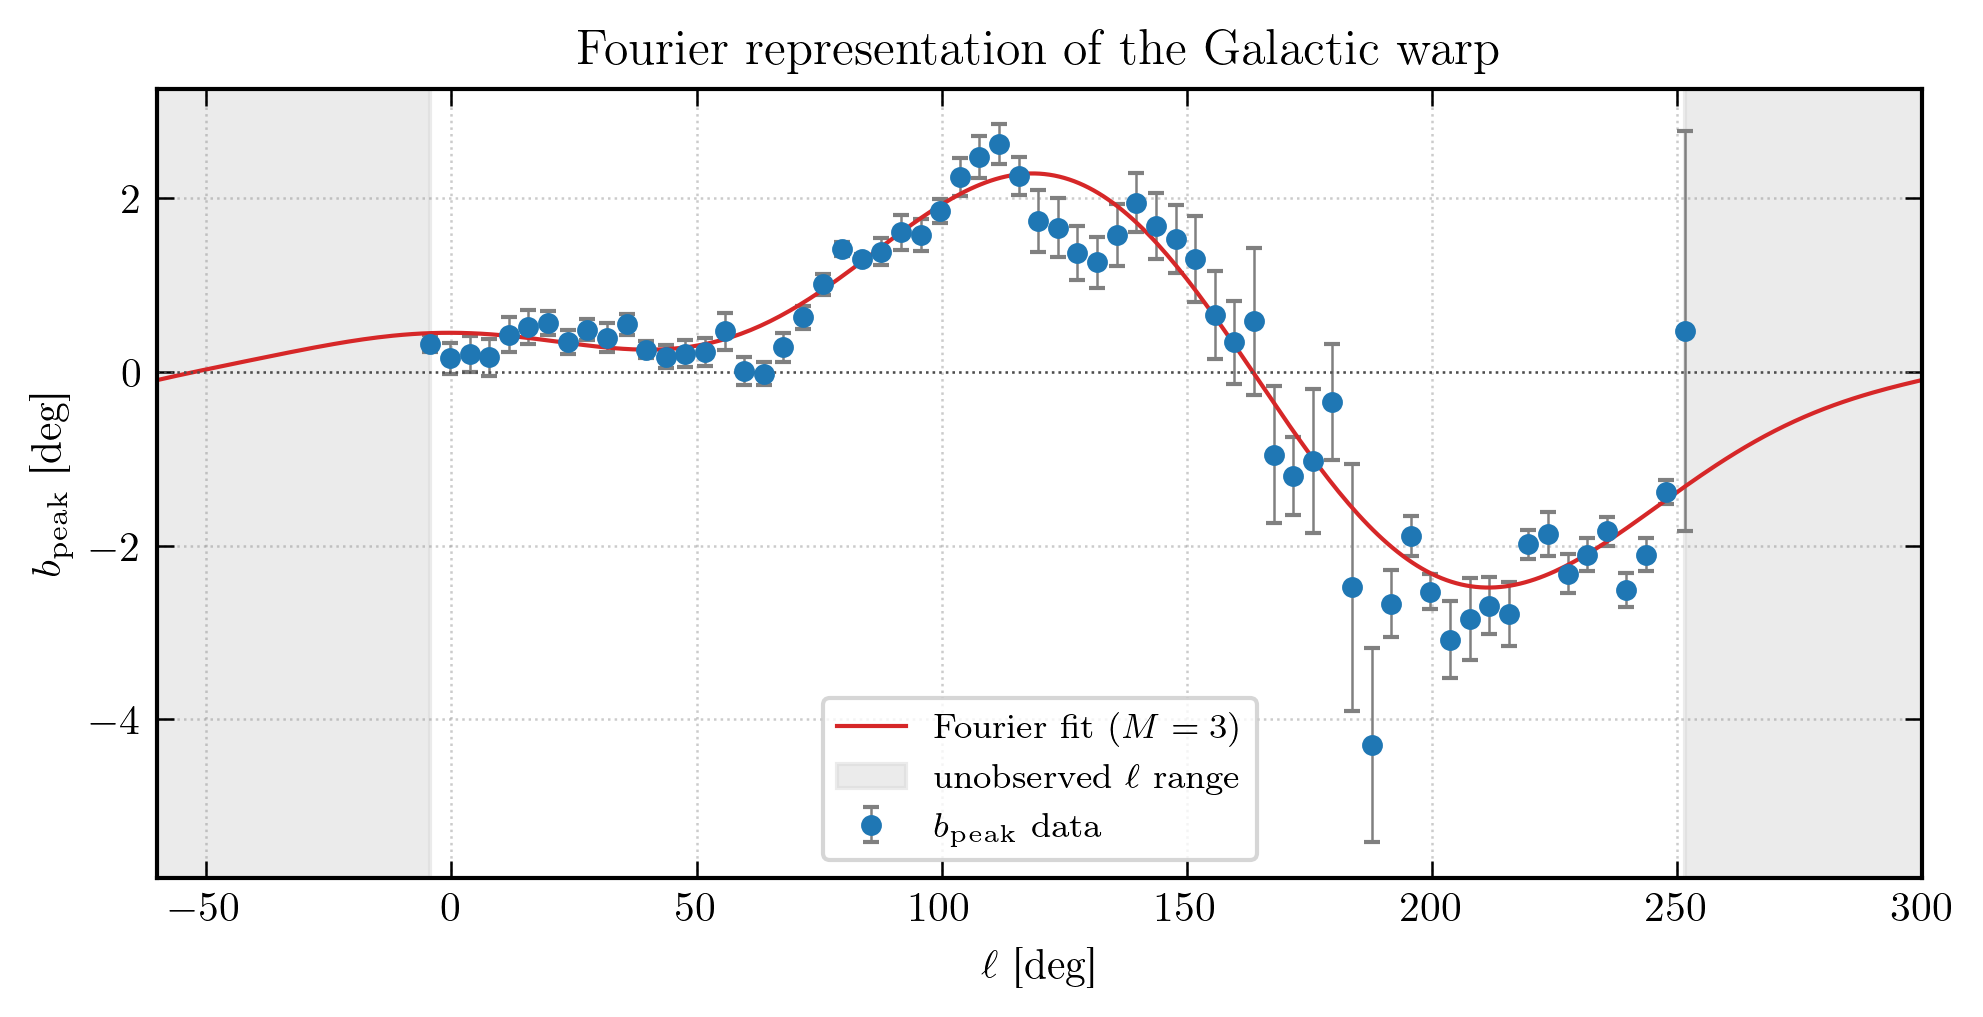

In [9]:
def fourier_design_warp(l_deg, M):
    l_rad = np.deg2rad(l_deg)
    cols = []
    for m in range(1, M + 1):
        cols.append(np.cos(m * l_rad))
        cols.append(np.sin(m * l_rad))
    return np.column_stack(cols)


ok_fit = np.isfinite(b_peak) & np.isfinite(b_peak_err) & (b_peak_err < 5.0)
l_fit = l_bin_centres[ok_fit]
b_fit = b_peak[ok_fit]
err_fit = b_peak_err[ok_fit]

X = fourier_design_warp(l_fit, M_HARMONICS)
W_diag = 1.0 / (err_fit ** 2)
A = (X.T * W_diag) @ X
y = (X.T * W_diag) @ b_fit
coef = np.linalg.solve(A, y)
cov = np.linalg.inv(A)
print(f'Fitted M = {M_HARMONICS} harmonics on {len(l_fit)} l-bins')
for m in range(1, M_HARMONICS + 1):
    a_m, b_m = coef[2 * (m - 1)], coef[2 * (m - 1) + 1]
    amp = np.hypot(a_m, b_m)
    phase = np.degrees(np.arctan2(b_m, a_m))
    print(f'  m = {m}:  a = {a_m:+.3f},  b = {b_m:+.3f},  '
          f'A = {amp:.3f} deg,  phase = {phase:+.1f} deg')

l_smooth = np.linspace(-60, 300, 361)
X_smooth = fourier_design_warp(l_smooth, M_HARMONICS)
b_model = X_smooth @ coef

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.45))
ax.errorbar(l_fit, b_fit, yerr=err_fit, fmt='o', color='C0', ms=4,
            ecolor='0.5', elinewidth=LW_FINE, capsize=2,
            label=r'$b_{\rm peak}$ data')
ax.plot(l_smooth, b_model, color='C3', lw=LW_LIGHT,
        label=rf'Fourier fit ($M = {M_HARMONICS}$)')

# Mark unconstrained range (Southern Galaxy gap, roughly l in (250, 300))
l_min, l_max = float(l_fit.min()), float(l_fit.max())
ax.axvspan(l_max, 360 + l_smooth[0], color='0.85', alpha=0.5,
           label='unobserved $\\ell$ range')
ax.axvspan(-60, l_min, color='0.85', alpha=0.5)
ax.axhline(0, color='0.3', lw=LW_FINE, ls=':')

ax.set_xlabel(r'$\ell$ [deg]')
ax.set_ylabel(r'$b_{\rm peak}$ [deg]')
ax.set_xlim(-60, 300)
ax.legend(loc='best', fontsize='small')
ax.set_title('Fourier representation of the Galactic warp')
plt.show()

## 9. Persist `artifacts/galactic_warp_products.pkl`

In [10]:
out = {
    'l_bin_centres':  l_bin_centres,
    'l_bin_edges':    l_bin_edges,
    'b_vals':         b_vals,
    'W_grid':         W_grid,
    'b_peak':         b_peak,
    'b_peak_err':     b_peak_err,
    'sigma_b_deg':    sigma_b,
    'sigma_b_err':    sigma_b_err,
    'h_z_deg':        h_z_deg,
    'h_z_deg_err':    h_z_deg_err,
    'h_z_kpc':        h_z_kpc,
    'h_z_kpc_err':    h_z_kpc_err,
    'd_repr_kpc':     d_repr_kpc,
    'fourier_coefs':  coef,
    'fourier_cov':    cov,
    'M_harmonics':    M_HARMONICS,
    'chi2_flat':      chi2_flat,
    'chi2_dof':       dof,
    'W_cell':         W_cell,
    'vmean_cell':     vmean_cell,
    'gl_cell':        gl_arr,
    'gb_cell':        gb_arr,
    'gl_wrapped':     gl_wrapped,
    'rgb_per_cell':   RGB_per_cell,
    'rgb_v_edges':    RGB_V_EDGES,
    'hsv_image':      rgba,
    'rgb_image':      RGBA_img,
    'image_l':        l_centres,
    'image_b':        b_centres,
    'mean_v_map':     vmean_img,
    'W_map':          W_img,
    'constants':      {'R_SUN_KPC': R_SUN_KPC, 'V_SUN_KMS': V_SUN_KMS,
                       'HPBW_DEG': HPBW_DEG, 'L_BIN_DEG': L_BIN_DEG},
}
with open(OUTPUT_PATH, 'wb') as f:
    pickle.dump(out, f)
print(f'Wrote {OUTPUT_PATH} ({OUTPUT_PATH.stat().st_size/1e6:.2f} MB)')

Wrote artifacts/galactic_warp_products.pkl (20.96 MB)
